In [22]:
import numpy as np
import matplotlib.pyplot as plt

def data_func(n):
    x = np.linspace(0,1,n)
    f = lambda x_1:4*np.sin(np.pi*x_1)*np.cos(6*np.pi*x_1**2)  
    err_add=np.random.normal(size=(n,))
    y = f(x) + err_add
    return x, f, y

# Generating data for n=30:
n=1000
x,f,y = data_func(n)








In [28]:
#part d - poly bootstrap
B = 10
best_lam_poly = 0.01
best_d = 30
Y_f=np.zeros((1000,B))
ERROR_POLY=np.zeros((1000,B))

for b in range(B):
    x=x.reshape(1000,1)
    
    selected_num = np.random.choice(list(range(n)), n, replace=True)
    x_sel = x[selected_num]
    y_sel = y[selected_num]
    x_sel=x_sel.reshape(1000,1)
    y_sel=y_sel.reshape(1000,1)
    
    K_poly = (1+np.dot(x_sel,x_sel.T))**30
    
    
    alpha_hat_poly = np.dot(np.linalg.inv(K_poly+best_lam_poly*np.eye(n)),y_sel)

    k_poly2=(1+np.dot(x,x_sel.T))**best_d
    f_h_poly=np.dot(k_poly2,alpha_hat_poly)

    y_sel = y_sel.reshape(1000,1)
    poly_err = y_sel-f_h_poly
    poly_err=poly_err.reshape(1000,)

    y_sel=y_sel.reshape(1000,)
    Y_f[:,b]=y_sel
    ERROR_POLY[:,b]=poly_err

net=np.mean((Y_f-ERROR_POLY)**2,axis=0)
print(net)

[3.21262787 3.31252835 3.24288188 3.52897284 3.18456511 3.52940954
 3.34051905 3.16402614 3.31541653 3.65312747]


In [ ]:
lamb=0.001         
final=np.zeros((di,300))
k_poly2=np.zeros((di,di))
Y_final=np.zeros((di,300))
store=np.zeros((300,1000),dtype=int)

for i in range(300):

    c=np.zeros(di)
    c=np.random.choice(range(di),di,replace=True)
    store[i,:]=c
    newy=y[c]
    newx=x[c]
    
    X= np.dot(newx,newx.T)
    k_poly= (one+X)**30   
    alpha_cap=np.dot((np.linalg.inv(k_poly+lamb*I)),newy)
    k_poly2=(1+np.dot(x,newx.T))**30
    f_hat=(np.dot(k_poly2,alpha_cap))
    
    final[:,i]=f_hat
    Y_final[:,i]=newy
    

error=(final-Y_final)**2
error=np.sum(error,axis=0)
error=error/1000

In [ ]:
per_5

-2562865237765.854

In [ ]:
per_95

9193408141.462385

(-20.0, 20.0)

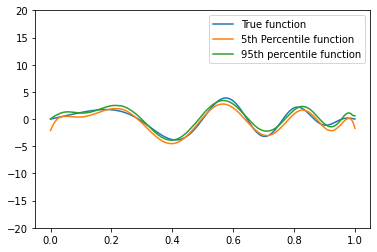

In [ ]:
# plt.plot(x,y,'o')
plt.plot(x,f(x))
#plt.plot(x,[f_hat_poly(xi) for xi in x])
plt.plot(x,per_5)
plt.plot(x,per_95)
#plt.legend(['function+noise', 'True function', 'F hat function', '5th Percentile function', '95th percentile function'])
plt.legend([ 'True function', '5th Percentile function', '95th percentile function'])
plt.ylim(-20,20)

In [ ]:
#part d - rbf - bootstrap
for b in range(B):
  selected_num = np.random.choice(list(range(n)), n, replace=True)
  #print(selected_num)
  x_sel = x[selected_num]
  y_sel = y[selected_num]
  #print(x_sel)
  x_val = np.linspace(0,1,n)
  f_hat_poly_rbf =lambda xi: k_ridge_func(x_sel,y_sel,best_lam_poly, n, best_d,k_rbf,xi)
  f_hat_sel[b,:] = [f_hat_poly_rbf(xi) for xi in x_val]
  # print(f_hat_sel[b,:] )
f_hat_sel.shape
per_5rbf = np.quantile(f_hat_sel, 0.05, axis=0)
per_95rbf = np.quantile(f_hat_sel, 0.95, axis=0)

(-20.0, 20.0)

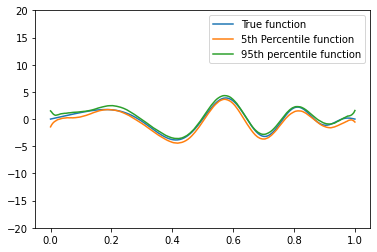

In [ ]:
# plt.plot(x,y,'o')
plt.plot(x,f(x))
#plt.plot(x,[f_hat_poly(xi) for xi in x])
plt.plot(x,per_5rbf)
plt.plot(x,per_95rbf)
#plt.legend(['function+noise', 'True function', 'F hat function', '5th Percentile function', '95th percentile function'])
plt.legend([ 'True function', '5th Percentile function', '95th percentile function'])
plt.ylim(-20,20)